# 01 — Data Audit & Label Schema Discovery

**Goal**: Understand the raw dataset before any processing.
- Count images and masks; detect mismatches
- Discover pixel values → class IDs from annotation masks
- Visualize sample image + mask pairs
- Save `audit_results.json` for use in Notebook 02

> **After running this notebook**: open `audit_results.json`, identify your class names,
> then update `CLASS_MAP` at the top of `02_preprocessing.ipynb` before proceeding.

## Environment Setup
Run once to install all dependencies. Adjust the CUDA version (`cu124`) to match your driver (`nvidia-smi`).

In [3]:
# Check CUDA version first — must match PyTorch wheel below
!nvidia-smi

Fri Apr 24 20:06:09 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 581.57                 Driver Version: 581.57         CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4060 ...  WDDM  |   00000000:01:00.0  On |                  N/A |
| N/A   43C    P8              2W /   45W |     236MiB /   8188MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [12]:
# Install PyTorch with CUDA 12.4 (change cu124 → cu118 if your driver is older)
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124 -q

# Install Ultralytics (YOLOv26 requires >= 8.4.41) and supporting libraries
!pip install "ultralytics>=8.4.41" opencv-python numpy pillow scikit-learn \
             matplotlib seaborn pandas ipykernel -q

print("Installation complete.")

Installation complete.


## 1. Imports & CUDA Verification

In [13]:
import numpy as np
import cv2
from PIL import Image
import os
import json
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

import torch

print(f"PyTorch  : {torch.__version__}")
print(f"CUDA available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU      : {torch.cuda.get_device_name(0)}")
    print(f"VRAM     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch  : 2.9.1+cu126
CUDA available : True
GPU      : NVIDIA GeForce RTX 4060 Laptop GPU
VRAM     : 8.6 GB


## 2. Dataset Paths
Paths are discovered via glob to handle the timestamp-suffixed directory names.

In [14]:
BASE_DIR = Path("..")  # project root (one level up from notebooks/)

TRAIN_IMG_DIR  = next(BASE_DIR.glob("images_prepped_train*/*"))
TRAIN_MASK_DIR = next(BASE_DIR.glob("annotations_prepped_train*/*"))
TEST_IMG_DIR   = next(BASE_DIR.glob("images_prepped_test*/*"))
TEST_MASK_DIR  = next(BASE_DIR.glob("annotations_prepped_test*/*"))

print("Train images :", TRAIN_IMG_DIR)
print("Train masks  :", TRAIN_MASK_DIR)
print("Test images  :", TEST_IMG_DIR)
print("Test masks   :", TEST_MASK_DIR)

Train images : ..\images_prepped_train-20230811T065243Z-001\images_prepped_train
Train masks  : ..\annotations_prepped_train-20230811T065240Z-001\annotations_prepped_train
Test images  : ..\images_prepped_test-20230811T065241Z-001\images_prepped_test
Test masks   : ..\annotations_prepped_test-20230811T065240Z-001\annotations_prepped_test


## 3. File Counts & Mismatch Detection

In [15]:
train_imgs  = sorted(TRAIN_IMG_DIR.glob("*.png"))
train_masks = sorted(TRAIN_MASK_DIR.glob("*.png"))
test_imgs   = sorted(TEST_IMG_DIR.glob("*.png"))
test_masks  = sorted(TEST_MASK_DIR.glob("*.png"))

print("=" * 40)
print(f"  Train images : {len(train_imgs):>5}")
print(f"  Train masks  : {len(train_masks):>5}")
print(f"  Test images  : {len(test_imgs):>5}")
print(f"  Test masks   : {len(test_masks):>5}")
print("=" * 40)

# --- Alignment check ---
train_img_stems  = {p.stem for p in train_imgs}
train_mask_stems = {p.stem for p in train_masks}
test_img_stems   = {p.stem for p in test_imgs}
test_mask_stems  = {p.stem for p in test_masks}

matched_train   = train_img_stems & train_mask_stems
orphan_imgs     = sorted(train_img_stems - train_mask_stems)
orphan_masks    = sorted(train_mask_stems - train_img_stems)
matched_test    = test_img_stems & test_mask_stems

print(f"\nMatched train pairs  : {len(matched_train)}  ← used for training")
print(f"Orphan train images  : {len(orphan_imgs)}   ← no mask, will be skipped")
print(f"Orphan train masks   : {len(orphan_masks)}   ← no image, will be skipped")
print(f"Matched test pairs   : {len(matched_test)}")

if orphan_imgs:
    print(f"\nFirst 5 orphan images: {orphan_imgs[:5]}")

  Train images :   398
  Train masks  :   367
  Test images  :   101
  Test masks   :   101

Matched train pairs  : 367  ← used for training
Orphan train images  : 31   ← no mask, will be skipped
Orphan train masks   : 0   ← no image, will be skipped
Matched test pairs   : 101

First 5 orphan images: ['0006R0_f03600(1)', '0006R0_f03630(1)', '0006R0_f03660(1)', '0006R0_f03690(1)', '0006R0_f03720(1)']


## 4. Image & Mask Properties

In [16]:
sample_img  = np.array(Image.open(train_imgs[0]))
# Use first mask whose stem appears in train_masks
sample_mask = np.array(Image.open(train_masks[0]))

print("=== Image ===")
print(f"  Shape  : {sample_img.shape}  (H x W x C)")
print(f"  Dtype  : {sample_img.dtype}")
print(f"  Range  : [{sample_img.min()}, {sample_img.max()}]")

print("\n=== Annotation Mask ===")
print(f"  Shape  : {sample_mask.shape}")
print(f"  Dtype  : {sample_mask.dtype}")
print(f"  Range  : [{sample_mask.min()}, {sample_mask.max()}]")
print(f"  Unique values: {sorted(np.unique(sample_mask).tolist())}")

=== Image ===
  Shape  : (360, 480, 3)  (H x W x C)
  Dtype  : uint8
  Range  : [0, 255]

=== Annotation Mask ===
  Shape  : (360, 480)
  Dtype  : uint8
  Range  : [0, 11]
  Unique values: [0, 1, 2, 3, 4, 5, 6, 8, 9, 11]


## 5. Pixel Value Discovery — Class Schema
Each unique pixel value in the grayscale masks corresponds to one semantic class.
Background is typically pixel value `0`.

In [17]:
print("Scanning all training masks... (this may take a moment)")

pixel_counter = Counter()
for mask_path in train_masks:
    mask = np.array(Image.open(mask_path))
    vals, counts = np.unique(mask, return_counts=True)
    for v, c in zip(vals.tolist(), counts.tolist()):
        pixel_counter[v] += c

total_pixels = sum(pixel_counter.values())

print(f"\n{'Pixel Value':<15} {'Total Pixels':>18} {'% of All Pixels':>18}")
print("-" * 55)
for val in sorted(pixel_counter):
    pct = 100 * pixel_counter[val] / total_pixels
    label = "← background (excluded from YOLO labels)" if val == 0 else ""
    print(f"{val:<15} {pixel_counter[val]:>18,} {pct:>17.2f}%  {label}")

Scanning all training masks... (this may take a moment)

Pixel Value           Total Pixels    % of All Pixels
-------------------------------------------------------
0                       10,682,767             16.85%  ← background (excluded from YOLO labels)
1                       14,750,079             23.26%  
2                          623,349              0.98%  
3                       20,076,880             31.66%  
4                        2,845,085              4.49%  
5                        6,166,762              9.72%  
6                          743,859              1.17%  
7                          714,595              1.13%  
8                        3,719,877              5.87%  
9                          405,385              0.64%  
10                         184,967              0.29%  
11                       2,503,995              3.95%  


## 6. Class Distribution Chart

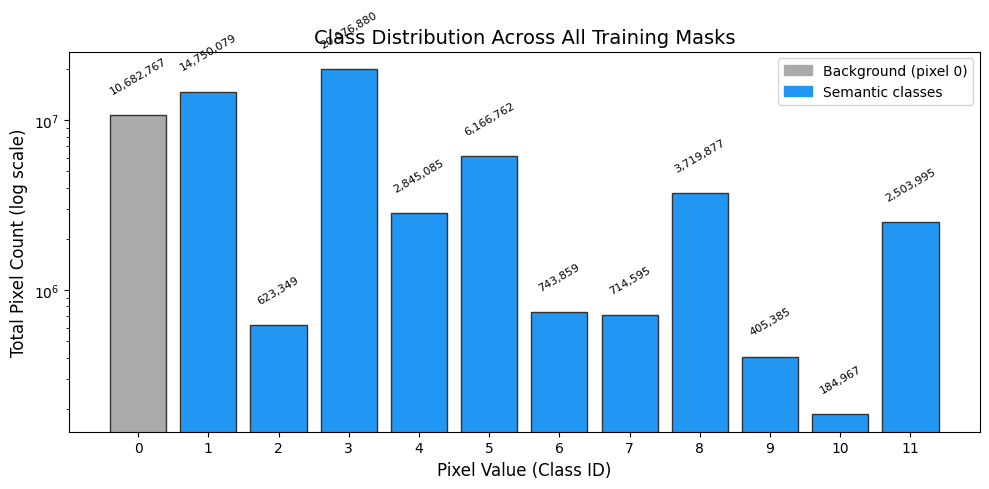

Saved: class_distribution.png


In [18]:
vals   = sorted(pixel_counter.keys())
counts = [pixel_counter[v] for v in vals]
colors = ["#aaaaaa" if v == 0 else "#2196F3" for v in vals]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar([str(v) for v in vals], counts, color=colors, edgecolor="#333")
ax.set_yscale("log")
ax.set_xlabel("Pixel Value (Class ID)", fontsize=12)
ax.set_ylabel("Total Pixel Count (log scale)", fontsize=12)
ax.set_title("Class Distribution Across All Training Masks", fontsize=14)

for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.3,
            f"{count:,}", ha="center", va="bottom", fontsize=8, rotation=30)

ax.legend(handles=[
    mpatches.Patch(color="#aaaaaa", label="Background (pixel 0)"),
    mpatches.Patch(color="#2196F3", label="Semantic classes")
])
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()
print("Saved: class_distribution.png")

## 7. Visual Inspection — Image + Mask Pairs
Each mask pixel value is rendered as a distinct color so you can identify what each class represents visually.

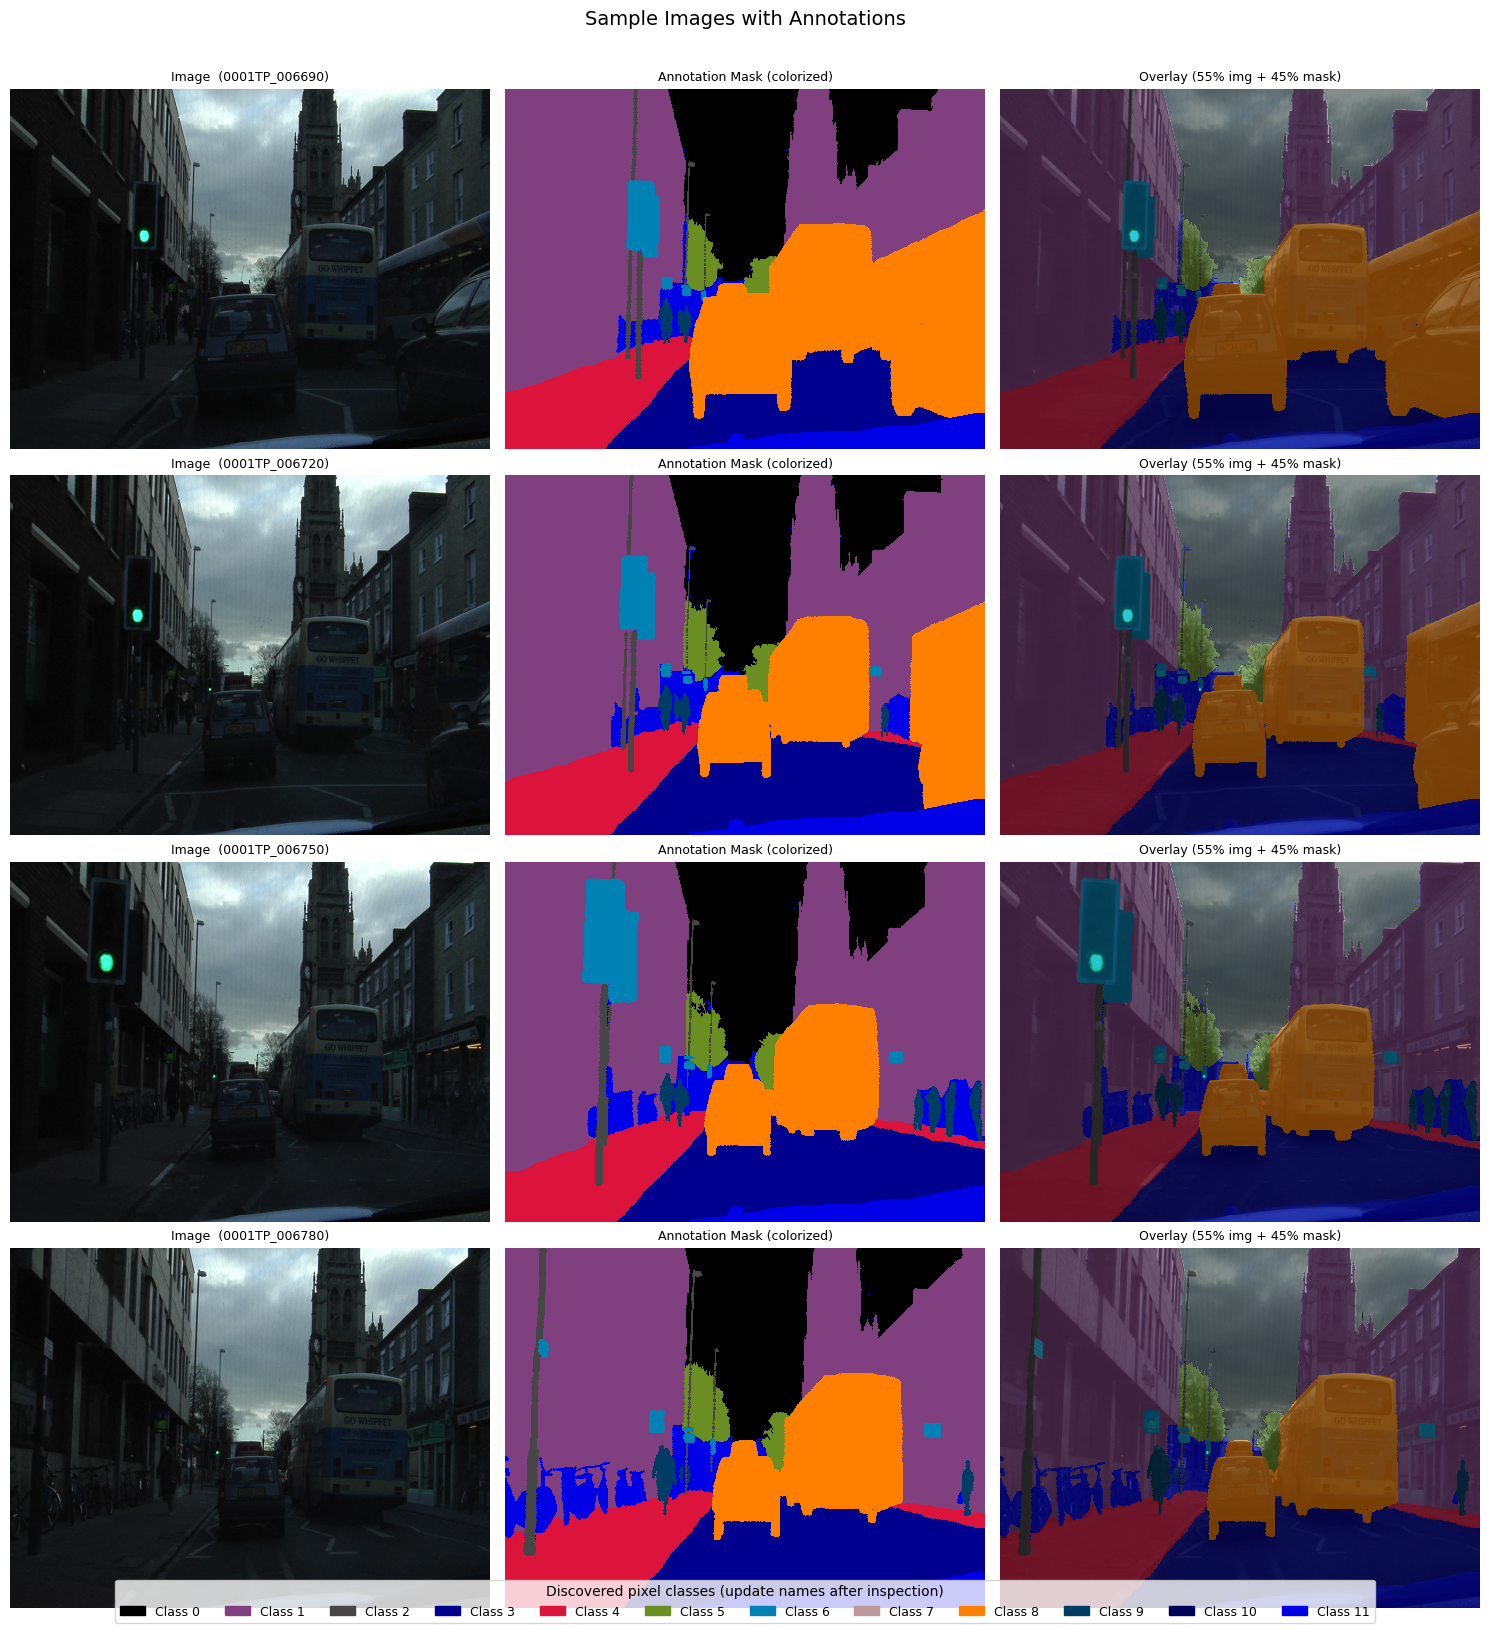

Saved: sample_annotations.png


In [19]:
PALETTE = [
    (0,   0,   0),    # 0: black       → background
    (128, 64,  128),  # 1: purple      → road
    (70,  70,  70),   # 2: grey        → building
    (0,   0,   142),  # 3: navy        → car/vehicle
    (220, 20,  60),   # 4: red         → person
    (107, 142, 35),   # 5: olive       → vegetation
    (0,   130, 180),  # 6: teal        → sky
    (190, 153, 153),  # 7: pink        → sidewalk
    (255, 128, 0),    # 8: orange      → traffic sign
    (0,   60,  100),  # 9: dark blue   → bus
    (0,   0,   90),   # 10: deep blue  → truck
    (0,   0,   230),  # 11: bright blue→ motorcycle
]

def colorize_mask(mask):
    rgb = np.zeros((*mask.shape[:2], 3), dtype=np.uint8)
    for v in np.unique(mask):
        vi = int(v)  # convert numpy scalar → Python int to avoid uint8 overflow in arithmetic
        if vi < len(PALETTE):
            rgb[mask == v] = PALETTE[vi]
        else:
            # fallback: deterministic color for classes beyond palette length
            rgb[mask == v] = [(vi * 37) % 256, (vi * 79) % 256, (vi * 113) % 256]
    return rgb

sample_stems = sorted(matched_train)[:4]
fig, axes = plt.subplots(4, 3, figsize=(15, 16))

for i, stem in enumerate(sample_stems):
    img  = np.array(Image.open(TRAIN_IMG_DIR / f"{stem}.png"))
    mask = np.array(Image.open(TRAIN_MASK_DIR / f"{stem}.png"))
    col_mask = colorize_mask(mask)
    overlay  = (img.astype(float) * 0.55 + col_mask.astype(float) * 0.45).clip(0, 255).astype(np.uint8)

    axes[i][0].imshow(img)
    axes[i][0].set_title(f"Image  ({stem[:22]})", fontsize=9)
    axes[i][1].imshow(col_mask)
    axes[i][1].set_title("Annotation Mask (colorized)", fontsize=9)
    axes[i][2].imshow(overlay)
    axes[i][2].set_title("Overlay (55% img + 45% mask)", fontsize=9)
    for ax in axes[i]:
        ax.axis("off")

# Legend
legend_patches = []
for v in sorted(pixel_counter.keys()):
    vi = int(v)
    c = PALETTE[vi] if vi < len(PALETTE) else ((vi*37)%256, (vi*79)%256, (vi*113)%256)
    legend_patches.append(mpatches.Patch(color=[x/255 for x in c], label=f"Class {vi}"))
fig.legend(handles=legend_patches, loc="lower center", ncol=len(legend_patches),
           fontsize=9, frameon=True, title="Discovered pixel classes (update names after inspection)")

plt.suptitle("Sample Images with Annotations", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("sample_annotations.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: sample_annotations.png")

## 8. Save Audit Results
The output `audit_results.json` is read by `02_preprocessing.ipynb`.

> **Action required**: After running this cell, open `audit_results.json` and update
> `"class_names"` with the real names you identified visually above (e.g. `"road"`, `"car"`, etc.).
> Background (pixel 0) should remain `"background"` and will be excluded from YOLO labels.

In [20]:
# Build suggested class map: pixel_value → placeholder name (update manually)
# Pixel 0 = background, excluded from YOLO training labels
suggested_class_names = {
    str(v): "background" if v == 0 else f"class_{v}"
    for v in sorted(pixel_counter.keys())
}

audit = {
    "train_images"       : len(train_imgs),
    "train_masks"        : len(train_masks),
    "test_images"        : len(test_imgs),
    "test_masks"         : len(test_masks),
    "matched_train_pairs": len(matched_train),
    "matched_test_pairs" : len(matched_test),
    "orphan_train_images": orphan_imgs,
    "image_hw"           : list(sample_img.shape[:2]),
    "pixel_values"       : sorted(pixel_counter.keys()),
    "pixel_counts"       : {str(k): int(v) for k, v in pixel_counter.items()},
    "class_names"        : suggested_class_names,
    "note"               : "Update class_names values with real semantic names before running 02_preprocessing.ipynb"
}

out_path = BASE_DIR / "audit_results.json"
with open(out_path, "w") as f:
    json.dump(audit, f, indent=2)

print(f"Saved: {out_path}")
print("\n--- Current class_names (UPDATE THESE) ---")
for pv, name in suggested_class_names.items():
    print(f"  pixel {pv:>3}  →  {name}")
print("\n✓ Open audit_results.json and replace class_N with real names, then run 02_preprocessing.ipynb")

Saved: ..\audit_results.json

--- Current class_names (UPDATE THESE) ---
  pixel   0  →  background
  pixel   1  →  class_1
  pixel   2  →  class_2
  pixel   3  →  class_3
  pixel   4  →  class_4
  pixel   5  →  class_5
  pixel   6  →  class_6
  pixel   7  →  class_7
  pixel   8  →  class_8
  pixel   9  →  class_9
  pixel  10  →  class_10
  pixel  11  →  class_11

✓ Open audit_results.json and replace class_N with real names, then run 02_preprocessing.ipynb
